# ЛР 2.1. Реализация и обучение простой CNN для классификации изображений (MNIST) на NumPy и PyTorch.

В этом занятии вам предстоит потренироваться построению нейронных сетей с помощью библиотеки Pytorch. Делать мы это будем на нескольких датасетах.

In [1]:
import numpy as np

import seaborn as sns
from matplotlib import pyplot as plt

from sklearn.model_selection import train_test_split

import torch
from torch import nn
from torch.nn import functional as F

from torch.utils.data import TensorDataset, DataLoader

sns.set(style="darkgrid", font_scale=1.4)

# Датасет MNIST
Датасет MNIST содержит рукописные цифры. Загрузим датасет и создадим DataLoader-ы. Пример можно найти в семинаре по полносвязным нейронным сетям.

In [3]:
import os
from torchvision.datasets import MNIST
from torchvision import transforms as tfs
from torch.utils.data import DataLoader

data_tfs = tfs.Compose([
    tfs.ToTensor(),
    tfs.Normalize((0.5), (0.5))
])

# install for train and test
root = './'
train_dataset = MNIST(root, train=True,  transform=data_tfs, download=True)
val_dataset  = MNIST(root, train=False, transform=data_tfs, download=True)

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2) # YOUR CODE GOES HERE
valid_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)  # YOUR CODE GOES HERE

100%|██████████| 9.91M/9.91M [00:00<00:00, 129MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 19.2MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 31.1MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.36MB/s]


## Часть 1. Полносвязные нейронные сети
Сначала решим MNIST с помощью полносвязной нейронной сети.

In [4]:
class Identical(nn.Module):
    def forward(self, x):
        return x

### Задание. Простая полносвязная нейронная сеть

Создайте полносвязную нейронную сеть с помощью класса Sequential. Сеть состоит из:
* Уплощения матрицы в вектор (nn.Flatten);
* Двух скрытых слоёв из 128 нейронов с активацией nn.ELU;
* Выходного слоя с 10 нейронами.

Задайте лосс для обучения (кросс-энтропия).

In [5]:
activation = nn.ELU

model = nn.Sequential(
    nn.Flatten(),
    #YOUR CODE. Add layers to your sequential class
    # Скрытый слой 1: 28*28 = 784 входных нейрона (размер изображения MNIST) → 128 нейронов
    nn.Linear(28 * 28, 128),
    activation(),

    # Скрытый слой 2: 128 → 128 нейронов
    nn.Linear(128, 128),
    activation(),

    # Выходной слой: 128 → 10 нейронов (10 классов цифр 0-9)
    nn.Linear(128, 10)
)

In [6]:
criterion = nn.CrossEntropyLoss()  #YOUR CODE. Select a loss function
optimizer = torch.optim.Adam(model.parameters())

loaders = {"train": train_dataloader, "valid": valid_dataloader}

In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"

### Train loop (seriously)

Давайте разберемся с кодом ниже, который подойдет для 90% задач в будущем.


```python
for epoch in range(max_epochs):  # <--------------- итерируемся по датасету несколько раз
    for k, dataloader in loaders.items():  # <----- несколько dataloader для train / valid / test
        for x_batch, y_batch in dataloader:  # <--- итерируемся по датасету. Так как мы используем SGD а не GD, то берем батчи заданного размера
            if k == "train":
                model.train()  # <------------------ переводим модель в режим train
                optimizer.zero_grad()  # <--------- обнуляем градиенты модели
                outp = model(x_batch)
                loss = criterion(outp, y_batch) # <-считаем "лосс" для логистической регрессии
                loss.backward()  # <--------------- считаем градиенты
                optimizer.step()  # <-------------- делаем шаг градиентного спуска
            else:  # <----------------------------- test/eval
                model.eval()  # <------------------ переводим модель в режим eval
                with torch.no_grad():  # <--------- НЕ считаем градиенты
                    outp = model(x_batch)  # <------------- получаем "логиты" из модели
            count_metrics(outp, y_batch)  # <-------------- считаем метрики
```

### Задание. Дополните цикл обучения.

In [8]:
max_epochs = 10
accuracy = {"train": [], "valid": []}
for epoch in range(max_epochs):
    for k, dataloader in loaders.items():
        epoch_correct = 0
        epoch_all = 0
        for x_batch, y_batch in dataloader:
            if k == "train":
                 # YOUR CODE. Set model to ``train`` mode and calculate outputs. Don't forget zero_grad!
                 model.train()  # Set model to train mode
                 optimizer.zero_grad()  # Zero the gradients
                 outp = model(x_batch)  # Calculate outputs
            else:
                 # YOUR CODE. Set model to ``eval`` mode and calculate outputs
                 model.eval()  # Set model to eval mode
                 with torch.no_grad():  # Disable gradient calculation
                     outp = model(x_batch)  # Calculate outputs
            # Calculate predictions and accuracy metrics
            preds = outp.argmax(-1)
            correct =  (preds == y_batch).sum()  # Number of correct predictions # YOUR CODE GOES HERE
            all = len(y_batch)  # Total number of samples in batch  # YOUR CODE GOES HERE
            epoch_correct += correct.item()
            epoch_all += all
            if k == "train":
                loss = criterion(outp, y_batch)
                # YOUR CODE. Calculate gradients and make a step of your optimizer
                loss.backward()  # Calculate gradients
                optimizer.step()  # Make optimization step
        if k == "train":
            print(f"Epoch: {epoch+1}")
        print(f"Loader: {k}. Accuracy: {epoch_correct/epoch_all}")
        accuracy[k].append(epoch_correct/epoch_all)


Epoch: 1
Loader: train. Accuracy: 0.9098666666666667
Loader: valid. Accuracy: 0.9585
Epoch: 2
Loader: train. Accuracy: 0.9566
Loader: valid. Accuracy: 0.9637
Epoch: 3
Loader: train. Accuracy: 0.9678166666666667
Loader: valid. Accuracy: 0.9623
Epoch: 4
Loader: train. Accuracy: 0.9728
Loader: valid. Accuracy: 0.9736
Epoch: 5
Loader: train. Accuracy: 0.9765833333333334
Loader: valid. Accuracy: 0.9745
Epoch: 6
Loader: train. Accuracy: 0.9797
Loader: valid. Accuracy: 0.9707
Epoch: 7
Loader: train. Accuracy: 0.9807666666666667
Loader: valid. Accuracy: 0.9738
Epoch: 8
Loader: train. Accuracy: 0.98275
Loader: valid. Accuracy: 0.9777
Epoch: 9
Loader: train. Accuracy: 0.9842166666666666
Loader: valid. Accuracy: 0.9753
Epoch: 10
Loader: train. Accuracy: 0.9853666666666666
Loader: valid. Accuracy: 0.9797


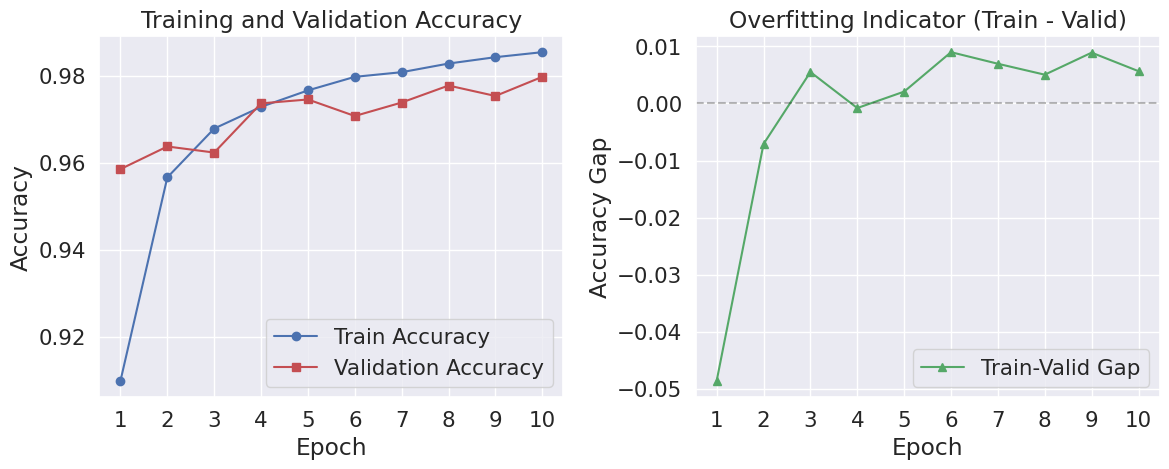

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# График точности на train и validation
plt.figure(figsize=(12, 5))

# График 1: Train vs Validation Accuracy
plt.subplot(1, 2, 1)
plt.plot(range(1, max_epochs + 1), accuracy['train'], 'b-', label='Train Accuracy', marker='o')
plt.plot(range(1, max_epochs + 1), accuracy['valid'], 'r-', label='Validation Accuracy', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.xticks(range(1, max_epochs + 1))

# График 2: Разница между train и validation
plt.subplot(1, 2, 2)
gap = np.array(accuracy['train']) - np.array(accuracy['valid'])
plt.plot(range(1, max_epochs + 1), gap, 'g-', label='Train-Valid Gap', marker='^')
plt.xlabel('Epoch')
plt.ylabel('Accuracy Gap')
plt.title('Overfitting Indicator (Train - Valid)')
plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)
plt.legend()
plt.grid(True)
plt.xticks(range(1, max_epochs + 1))

plt.tight_layout()
plt.show()

### Задание. Протестируйте разные функции активации.
Попробуйте разные функции активации. Для каждой функции активации посчитайте массив validation accuracy. Лучше реализовать это в виде функции, берущей на вход активацию и получающей массив из accuracies.

In [ ]:
elu_accuracy = accuracy["valid"]

In [10]:
# YOUR CODE. Do the same thing with other activations (it's better to wrap into a function that returns a list of accuracies)

def test_activation_function(activation):
    #YOUR CODE
    pass

import torch
import torch.nn as nn
import torch.optim as optim
import copy

# Определим тождественную функцию активации
class Identical(nn.Module):
    def __init__(self):
        super(Identical, self).__init__()

    def forward(self, x):
        return x

def test_activation_function(activation, activation_name="activation", epochs=10):
    """
    Тестирует функцию активации и возвращает массив validation accuracy за каждую эпоху

    Args:
        activation: класс функции активации (например, nn.ReLU, nn.ELU и т.д.)
        activation_name: имя функции активации для вывода
        epochs: количество эпох обучения

    Returns:
        list: массив validation accuracy за каждую эпоху
    """
    # Создаем модель с заданной функцией активации
    model = nn.Sequential(
        nn.Flatten(),
        nn.Linear(28 * 28, 128),
        activation(),
        nn.Linear(128, 128),
        activation(),
        nn.Linear(128, 10)
    )

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters())

    accuracy = {"train": [], "valid": []}

    for epoch in range(epochs):
        for k, dataloader in loaders.items():
            epoch_correct = 0
            epoch_all = 0

            for x_batch, y_batch in dataloader:
                if k == "train":
                    model.train()
                    optimizer.zero_grad()
                    outp = model(x_batch)
                else:
                    model.eval()
                    with torch.no_grad():
                        outp = model(x_batch)

                preds = outp.argmax(-1)
                correct = (preds == y_batch).sum()
                all_samples = len(y_batch)

                epoch_correct += correct.item()
                epoch_all += all_samples

                if k == "train":
                    loss = criterion(outp, y_batch)
                    loss.backward()
                    optimizer.step()

            acc = epoch_correct / epoch_all if epoch_all > 0 else 0
            accuracy[k].append(acc)

            if k == "valid" and epoch == epochs - 1:
                print(f"{activation_name}: Final validation accuracy = {acc:.4f}")

    return accuracy["valid"]

# Тестируем различные функции активации
print("Testing different activation functions...")

# ELU (уже посчитана в предыдущем коде)
elu_accuracy = accuracy["valid"]  # Используем результаты из предыдущего обучения

# Линейная (тождественная) активация
plain_accuracy = test_activation_function(Identical, "Linear (No activation)")

# ReLU
relu_accuracy = test_activation_function(nn.ReLU, "ReLU")

# LeakyReLU (с параметром 0.1)
leaky_relu_accuracy = test_activation_function(lambda: nn.LeakyReLU(0.1), "LeakyReLU(0.1)")

# Можно также протестировать другие функции активации
sigmoid_accuracy = test_activation_function(nn.Sigmoid, "Sigmoid")
tanh_accuracy = test_activation_function(nn.Tanh, "Tanh")

Testing different activation functions...
Linear (No activation): Final validation accuracy = 0.9154


KeyboardInterrupt: 

In [ ]:
# Визуализируем результаты
import matplotlib.pyplot as plt

# Собираем все результаты в словарь
activation_results = {
    "ELU": elu_accuracy,
    "Linear": plain_accuracy,
    "ReLU": relu_accuracy,
    "LeakyReLU": leaky_relu_accuracy,
    "Sigmoid": sigmoid_accuracy,
    "Tanh": tanh_accuracy
}

# Рисуем график
plt.figure(figsize=(12, 6))

for activation_name, accuracies in activation_results.items():
    plt.plot(range(1, len(accuracies) + 1), accuracies, label=activation_name, marker='o')

plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Comparison of Activation Functions')
plt.legend()
plt.grid(True)
plt.xticks(range(1, len(elu_accuracy) + 1))
plt.show()

# Выводим финальные точности
print("\nFinal validation accuracies:")
for activation_name, accuracies in activation_results.items():
    print(f"{activation_name}: {accuracies[-1]:.4f}")

# Находим лучшую функцию активации
best_activation = max(activation_results.items(), key=lambda x: x[1][-1])
print(f"\nBest activation function: {best_activation[0]} with accuracy {best_activation[1][-1]:.4f}")

In [ ]:
plain_accuracy = test_activation_function(Identical)
relu_accuracy = #YOUR CODE
leaky_relu_accuracy = #YOUR CODE

### Accuracy
Построим график accuracy/epoch для каждой функции активации.

In [ ]:
sns.set(style="darkgrid", font_scale=1.4)

plt.figure(figsize=(16, 10))
plt.title("Valid accuracy")
plt.plot(range(max_epochs), plain_accuracy, label="No activation", linewidth=2)
plt.plot(range(max_epochs), relu_accuracy, label="ReLU activation", linewidth=2)
plt.plot(range(max_epochs), leaky_relu_accuracy, label="LeakyReLU activation", linewidth=2)
plt.plot(range(max_epochs), elu_accuracy, label="ELU activation", linewidth=2)
plt.legend()
plt.xlabel("Epoch")
plt.show()

In [ ]:
plt.figure(figsize=(16, 10))
plt.title("Valid accuracy")
plt.plot(range(max_epochs), relu_accuracy, label="ReLU activation", linewidth=2)
plt.plot(range(max_epochs), leaky_relu_accuracy, label="LeakyReLU activation", linewidth=2)
plt.plot(range(max_epochs), elu_accuracy, label="ELU activation", linewidth=2)
plt.legend()
plt.xlabel("Epoch")
plt.show()

**Вопрос 1.** Какая из активаций показала наивысший `accuracy` к концу обучения?

**Ответ:**

## Часть 2. Сверточные нейронные сети

### Ядра
Сначала немного поработам с самим понятием ядра свёртки.

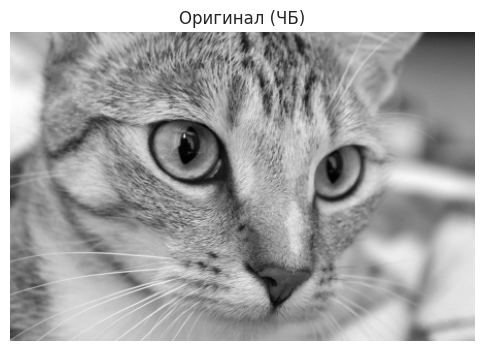

In [49]:
import matplotlib.pyplot as plt
from skimage import data, color

# 1. Загрузка изображения и перевод в ЧБ
image_color = data.chelsea()  # Цветная кошка
image_gray = color.rgb2gray(image_color)  # Перевод в черно-белое

# 2. Подготовка тензора [1, 1, H, W]
img_t = torch.from_numpy(image_gray).type(torch.float32).unsqueeze(0).unsqueeze(0)

# 3. Показываем оригинал
plt.figure(figsize=(6,6))
plt.imshow(image_gray, cmap='gray')
plt.title("Оригинал (ЧБ)")
plt.axis('off')
plt.show()

Попробуйте посмотреть как различные свертки влияют на фото. Например, попробуйте
A)
```
[0, 0, 0],
[0, 1, 0],
[0, 0, 0]
```
Б)
```
[0, 1, 0],
[0, -2, 0],
[0, 1, 0]
```
В)
```
[0, 0, 0],
[1, -2, 1],
[0, 0, 0]
```
Г)
```
[0, 1, 0],
[1, -4, 1],
[0, 1, 0]
```
Д)
```
[0, -1, 0],
[-1, 5, -1],
[0, -1, 0]
```
Е)
```
[0.0625, 0.125, 0.0625],
[0.125, 0.25, 0.125],
[0.0625, 0.125, 0.0625]
```

Не стесняйтесь пробовать свои варианты!

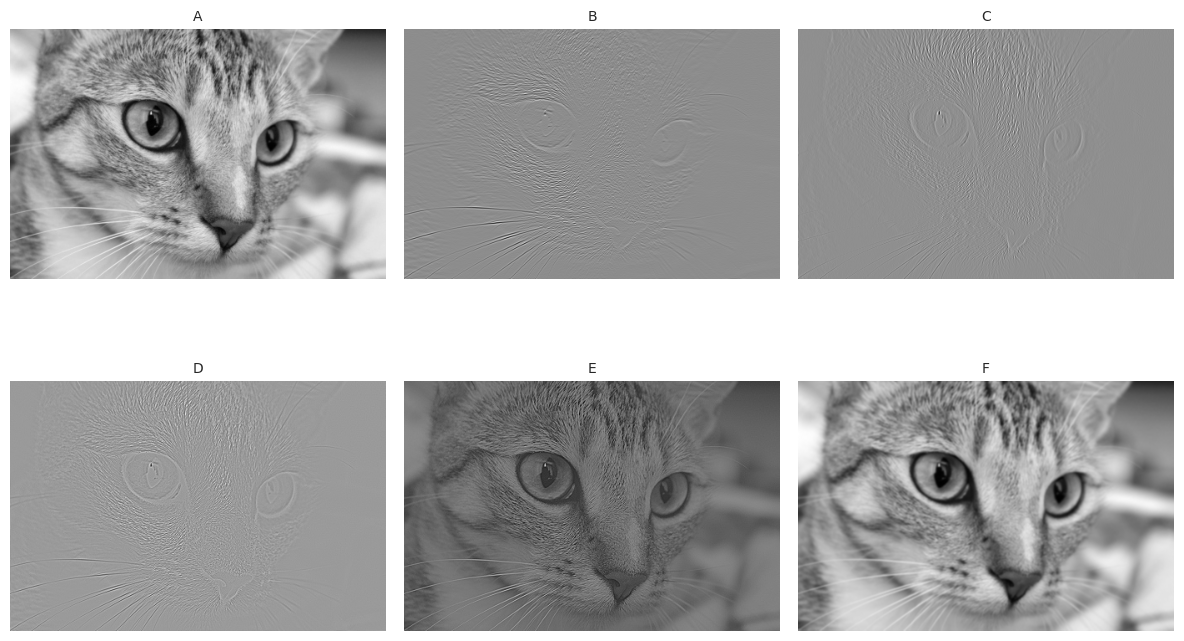

In [51]:
# 4. Функция применения ядра
def apply_kernel(img_tensor, kernel_2d):
    kernel = kernel_2d.reshape(1, 1, 3, 3)
    padded = nn.ReflectionPad2d(1)(img_tensor)
    result = F.conv2d(padded, kernel)
    result_np = result.squeeze().numpy()

    # Нормализация для отображения
    if kernel_2d.min() < 0:
        result_np = (result_np - result_np.min()) / (result_np.max() - result_np.min() + 1e-8)
    else:
        result_np = np.clip(result_np, 0, 1)

    return result_np

# 5. Все ядра
kernels = {
    "A": torch.tensor([[0,0,0],[0,1,0],[0,0,0]], dtype=torch.float32),
    "B": torch.tensor([[0,1,0],[0,-2,0],[0,1,0]], dtype=torch.float32),
    "C": torch.tensor([[0,0,0],[1,-2,1],[0,0,0]], dtype=torch.float32),
    "D": torch.tensor([[0,1,0],[1,-4,1],[0,1,0]], dtype=torch.float32),
    "E": torch.tensor([[0,-1,0],[-1,5,-1],[0,-1,0]], dtype=torch.float32),
    "F": torch.tensor([[0.0625,0.125,0.0625],[0.125,0.25,0.125],[0.0625,0.125,0.0625]], dtype=torch.float32),
}

# 6. Визуализация
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for idx, (name, kernel) in enumerate(kernels.items()):
    result = apply_kernel(img_t, kernel)
    axes[idx].imshow(result, cmap='gray')
    axes[idx].set_title(name, fontsize=10)
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

**Вопрос 2.** Как можно описать действия ядер, приведенных выше? Сопоставьте для каждой буквы число.

1) Размытие

2) Увеличение резкости

3) Тождественное преобразование

4) Выделение вертикальных границ

5) Выделение горизонтальных границ

6) Выделение границ

**Ответ:**

### Задание. Реализуйте LeNet

Если мы сделаем параметры сверток обучаемыми, то можем добиться хороших результатов для задач компьютерного зрения. Реализуйте архитектуру LeNet, предложенную еще в 1998 году!
На этот раз используйте модульную структуру (без помощи класса Sequential).

Наша нейронная сеть будет состоять из
* Свёртки 3x3 (1 карта на входе, 6 на выходе) с активацией ReLU;
* MaxPooling-а 2x2;
* Свёртки 3x3 (6 карт на входе, 16 на выходе) с активацией ReLU;
* MaxPooling-а 2x2;
* Уплощения (nn.Flatten);
* Полносвязного слоя со 120 нейронами и активацией ReLU;
* Полносвязного слоя с 84 нейронами и активацией ReLU;
* Выходного слоя из 10 нейронов.




In [52]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# 1. ЗАГРУЗКА ДАННЫХ MNIST
# -----------------------------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
valid_dataset = datasets.MNIST('./data', train=False, download=True, transform=transform)

BATCH_SIZE = 64
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_dataloader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)

loaders = {"train": train_dataloader, "valid": valid_dataloader}
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 132MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 10.3MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 127MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.68MB/s]


Using device: cpu


In [53]:
class LeNet(nn.Module):
    def __init__(self):
        super(LeNet, self).__init__()

        # YOUR CODE
        # Сверточные слои
        self.conv1 = nn.Conv2d(1, 6, kernel_size=3, padding=1)  # 1→6 каналов
        self.pool1 = nn.MaxPool2d(2, 2)  # 2x2 MaxPooling

        self.conv2 = nn.Conv2d(6, 16, kernel_size=3, padding=1)  # 6→16 каналов
        self.pool2 = nn.MaxPool2d(2, 2)  # 2x2 MaxPooling

        # Полносвязные слои
        # После двух сверток и пулингов: 28→14→7, с 16 каналами → 16*7*7 = 784
        self.fc1 = nn.Linear(16 * 7 * 7, 120)  # 16*7*7 = 784 → 120
        self.fc2 = nn.Linear(120, 84)          # 120 → 84
        self.fc3 = nn.Linear(84, 10)           # 84 → 10 (классы)

        # Dropout для регуляризации
        self.dropout = nn.Dropout(0.25)

    def forward(self, x):
        # Первый блок: свертка + ReLU + пулинг
        x = self.pool1(F.relu(self.conv1(x)))

        # Второй блок: свертка + ReLU + пулинг
        x = self.pool2(F.relu(self.conv2(x)))

        # Уплощение
        x = x.view(x.size(0), -1)  # или x = torch.flatten(x, 1)

        # Полносвязные слои с ReLU и Dropout
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)

        return x

In [54]:
# Создание модели
model = LeNet().to(device)
print("\n=== Архитектура LeNet ===")
print(model)


=== Архитектура LeNet ===
LeNet(
  (conv1): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=784, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
  (dropout): Dropout(p=0.25, inplace=False)
)


### Задание. Обучите CNN
Используйте код обучения, который вы написали для полносвязной нейронной сети.

In [55]:
# -----------------------------
# 3. НАСТРОЙКА ОБУЧЕНИЯ
# -----------------------------
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [56]:
# -----------------------------
# 4. ФУНКЦИЯ ОБУЧЕНИЯ
# -----------------------------
def train_model(model, loaders, optimizer, criterion, epochs=10):
    """Универсальная функция обучения"""
    accuracy = {"train": [], "valid": []}

    for epoch in range(epochs):
        for phase, dataloader in loaders.items():
            epoch_correct = 0
            epoch_total = 0

            for x_batch, y_batch in dataloader:
                x_batch, y_batch = x_batch.to(device), y_batch.to(device)

                if phase == "train":
                    model.train()
                    optimizer.zero_grad()
                    outputs = model(x_batch)
                    loss = criterion(outputs, y_batch)
                    loss.backward()
                    optimizer.step()
                else:
                    model.eval()
                    with torch.no_grad():
                        outputs = model(x_batch)

                preds = outputs.argmax(dim=1)
                correct = (preds == y_batch).sum().item()
                total = y_batch.size(0)

                epoch_correct += correct
                epoch_total += total

            epoch_acc = epoch_correct / epoch_total
            accuracy[phase].append(epoch_acc)

            if phase == "train":
                print(f"Epoch {epoch+1}/{epochs}")
            print(f"  {phase.capitalize()} Accuracy: {epoch_acc:.4f}")

    return accuracy

In [58]:
# -----------------------------
# 5. ОБУЧЕНИЕ
# -----------------------------
max_epochs = 10
print("\n=== Обучение LeNet ===")
lenet_accuracy = train_model(model, loaders, optimizer, criterion, epochs=max_epochs)


=== Обучение LeNet ===
Epoch 1/10
  Train Accuracy: 0.9750
  Valid Accuracy: 0.9848
Epoch 2/10
  Train Accuracy: 0.9804
  Valid Accuracy: 0.9854
Epoch 3/10
  Train Accuracy: 0.9836
  Valid Accuracy: 0.9856
Epoch 4/10
  Train Accuracy: 0.9855
  Valid Accuracy: 0.9891
Epoch 5/10
  Train Accuracy: 0.9869
  Valid Accuracy: 0.9890
Epoch 6/10
  Train Accuracy: 0.9882
  Valid Accuracy: 0.9900
Epoch 7/10
  Train Accuracy: 0.9889
  Valid Accuracy: 0.9908
Epoch 8/10
  Train Accuracy: 0.9901
  Valid Accuracy: 0.9897
Epoch 9/10
  Train Accuracy: 0.9910
  Valid Accuracy: 0.9915
Epoch 10/10
  Train Accuracy: 0.9909
  Valid Accuracy: 0.9897


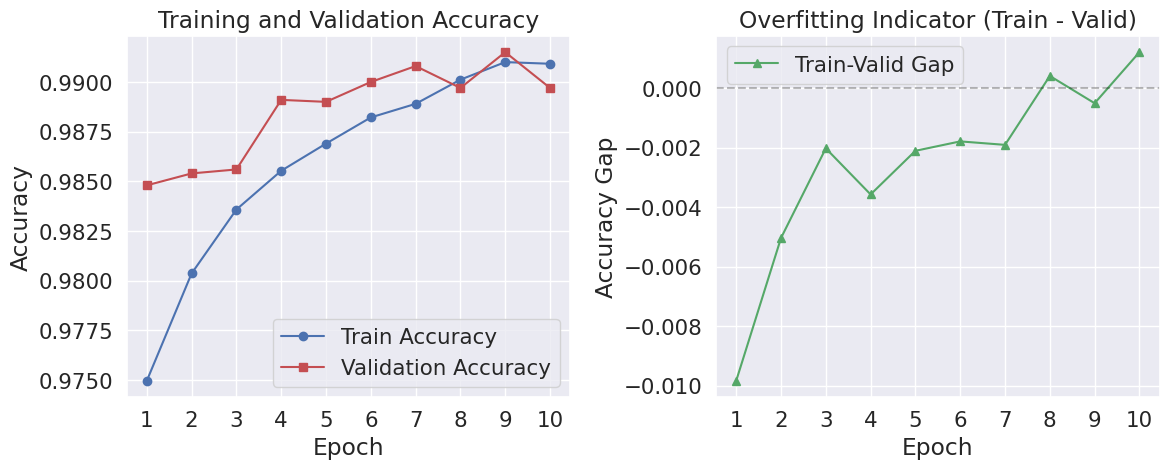

In [65]:
# -----------------------------
# 5. ПОСТРОЕНИЕ ГРАФИКОВ
# -----------------------------
plt.figure(figsize=(12, 5))

# График 1: Train vs Validation Accuracy
plt.subplot(1, 2, 1)
plt.plot(range(1, max_epochs + 1), lenet_accuracy['train'], 'b-', label='Train Accuracy', marker='o')
plt.plot(range(1, max_epochs + 1), lenet_accuracy['valid'], 'r-', label='Validation Accuracy', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.xticks(range(1, max_epochs + 1))

# График 2: Разница между train и validation
plt.subplot(1, 2, 2)
gap = np.array(lenet_accuracy['train']) - np.array(lenet_accuracy['valid'])
plt.plot(range(1, max_epochs + 1), gap, 'g-', label='Train-Valid Gap', marker='^')
plt.xlabel('Epoch')
plt.ylabel('Accuracy Gap')
plt.title('Overfitting Indicator (Train - Valid)')
plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)
plt.legend()
plt.grid(True)
plt.xticks(range(1, max_epochs + 1))

plt.tight_layout()
plt.show()

**Вопрос 3**
Какое `accuracy` получается после обучения с точностью до двух знаков после запятой?

**Ответ:**